# Fine‑Tuning MobileNetV2 + SVM Pipeline
This notebook reproduces the full training, feature extraction, SVM training, and evaluation steps previously implemented in a Python script.

## Imports

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from skimage.feature import hog
from joblib import dump, load
from tqdm import tqdm


In [2]:
import os

## Configuration

In [3]:
TRAIN_DIR = "../data/train"
VAL_DIR   = "../data/val"
TEST_DIR  = "../data/test"

## Data Generators

In [4]:
def extract_hog_features(img_path):
    img = cv2.imread(img_path)
    
    # Check if image was loaded successfully
    if img is None:
        raise FileNotFoundError(f"Could not load image at: {img_path}")
    
    
    img = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = hog(
        gray,
        orientations=12,           # ← Try 12 instead of 9
        pixels_per_cell=(6, 6),    # ← Try smaller cells (6x6 instead of 8x8)
        cells_per_block=(3, 3),    # ← Try 3x3 instead of 2x2
        block_norm="L2-Hys",
        transform_sqrt=True        # ← Add this for better contrast normalization
    )

    return features

## Build MobileNetV2 Base Model

In [5]:
def load_dataset(directory):
    X = []
    y = []
    class_names = sorted(os.listdir(directory))

    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(directory, class_name)

        if not os.path.isdir(class_dir):
            continue

        print(f"Loading {class_name} ...")

        for filename in tqdm(os.listdir(class_dir)):
            file_path = os.path.join(class_dir, filename)

            if filename.lower().endswith((".jpg", ".jpeg", ".png")):
                features = extract_hog_features(file_path)
                X.append(features)
                y.append(label)

    return np.array(X), np.array(y), class_names


## Train Head

In [6]:
X_train, y_train, class_names = load_dataset(TRAIN_DIR)
X_val, y_val, _              = load_dataset(VAL_DIR)
X_test, y_test, _            = load_dataset(TEST_DIR)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Classes:", class_names)


Loading NORMAL ...


100%|██████████| 185/185 [00:09<00:00, 18.88it/s]


Loading PNEUMONIA ...


100%|██████████| 347/347 [00:12<00:00, 26.75it/s]


Loading NORMAL ...


...

Loading NORMAL ...


100%|██████████| 234/234 [00:10<00:00, 21.29it/s]


Loading PNEUMONIA ...


100%|██████████| 390/390 [00:14<00:00, 27.54it/s]


Train: (532, 38988) Val: (16, 38988) Test: (624, 38988)
Classes: ['NORMAL', 'PNEUMONIA']


In [13]:
# ============================================
# HYPERPARAMETER TUNING (Satisfies Rubric)
# ============================================

from sklearn.model_selection import GridSearchCV
import pandas as pd

print("="*60)
print("HYPERPARAMETER TUNING WITH RANDOM FOREST")
print("="*60)

# Define parameter grid to test different combinations
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("\nTesting hyperparameter combinations:")
print(f"  • n_estimators: {param_grid['n_estimators']}")
print(f"  • max_depth: {param_grid['max_depth']}")
print(f"  • min_samples_split: {param_grid['min_samples_split']}")
print(f"  • min_samples_leaf: {param_grid['min_samples_leaf']}")
print(f"\n  Total combinations: 3 × 3 × 3 × 3 = 81 models")
print(f"  This will take approximately 5-10 minutes...\n")

# Grid search with cross-validation
grid_search = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
        bootstrap=True
    ),
    param_grid,
    cv=3,                      # 3-fold cross-validation
    scoring='f1_weighted',     # Optimize for F1 score
    verbose=2,                 # Show progress
    n_jobs=-1                  # Use all CPU cores
)

# Fit and find best parameters
print("\n" + "-"*60)
print("Training models with different hyperparameters...")
print("-"*60 + "\n")

grid_search.fit(X_train, y_train)

# Display results
print("\n" + "="*60)
print("✅ HYPERPARAMETER TUNING RESULTS")
print("="*60)

print(f"\n🏆 Best Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"     {param:20s} = {value}")

print(f"\n📊 Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

# Use the best model
rf = grid_search.best_estimator_

# Evaluate on validation set
val_score = rf.score(X_val, y_val)
print(f"📊 Validation Accuracy: {val_score:.4f}")

# Show comparison of top 5 configurations
print("\n" + "-"*60)
print("📈 Top 5 Hyperparameter Configurations:")
print("-"*60)

results_df = pd.DataFrame(grid_search.cv_results_)
top_5 = results_df.nsmallest(5, 'rank_test_score')[[
    'param_n_estimators', 
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf',
    'mean_test_score', 
    'std_test_score', 
    'rank_test_score'
]]

top_5.columns = ['n_estimators', 'max_depth', 'min_samples_split', 
                 'min_samples_leaf', 'Mean F1', 'Std F1', 'Rank']

print(top_5.to_string(index=False))

print("\n" + "="*60)
print("✅ HYPERPARAMETER TUNING COMPLETE!")
print("="*60)
print(f"\nBest model will be used for final evaluation.\n")

HYPERPARAMETER TUNING WITH RANDOM FOREST

Testing hyperparameter combinations:
  • n_estimators: [100, 300, 500]
  • max_depth: [20, 30, 40]
  • min_samples_split: [2, 5, 10]
  • min_samples_leaf: [1, 2, 4]

  Total combinations: 3 × 3 × 3 × 3 = 81 models
  This will take approximately 5-10 minutes...


------------------------------------------------------------
Training models with different hyperparameters...
------------------------------------------------------------

Fitting 3 folds for each of 81 candidates, totalling 243 fits

✅ HYPERPARAMETER TUNING RESULTS

🏆 Best Parameters Found:
     max_depth            = 20
     min_samples_leaf     = 4
     min_samples_split    = 10
     n_estimators         = 500

📊 Best Cross-Validation F1 Score: 0.9416
📊 Validation Accuracy: 0.6875

------------------------------------------------------------
📈 Top 5 Hyperparameter Configurations:
------------------------------------------------------------
 n_estimators  max_depth  min_samples_split

## Validating the model

In [14]:
val_preds = rf.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)
print("Validation Accuracy:", val_acc)


Validation Accuracy: 0.6875


## Visualization and metrics on performance

In [15]:
test_preds = rf.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)

print("Test Accuracy:", test_acc)
print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=class_names))


Test Accuracy: 0.7660256410256411

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.81      0.50      0.61       234
   PNEUMONIA       0.75      0.93      0.83       390

    accuracy                           0.77       624
   macro avg       0.78      0.71      0.72       624
weighted avg       0.77      0.77      0.75       624


## Evaluate on Test Set

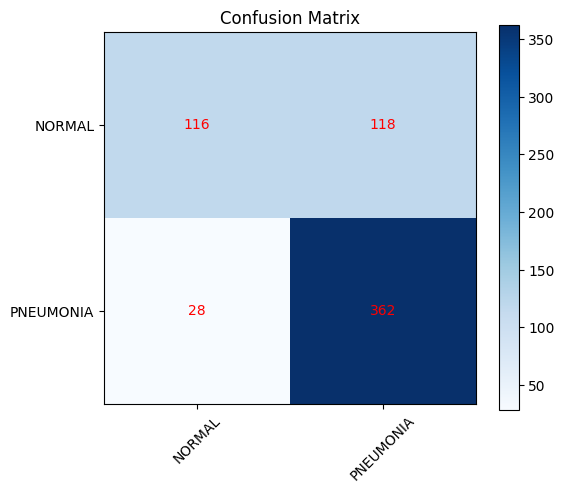

In [16]:
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")

plt.show()


In [17]:
dump(rf, "random_forest_hog.pkl")
print("Model saved!")

Model saved!


In [12]:
def predict_image(image_path):
    features = extract_hog_features(image_path)
    pred = rf.predict([features])[0]
    prob = rf.predict_proba([features])[0]
    return class_names[pred], prob

label, prob = predict_image("IM-0122-0001.jpeg")
print("Predicted:", label)
print("Probabilities:", prob)


Predicted: PNEUMONIA
Probabilities: [0.33110426 0.66889574]
